Baixando o repositório de dados

In [1]:
!wget https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip -O uci_har.zip

--2026-09-24 17:20:47--  https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘uci_har.zip’

uci_har.zip             [        <=>         ]  58.18M  36.5MB/s    in 1.6s    

2026-09-24 17:20:49 (36.5 MB/s) - ‘uci_har.zip’ saved [61005872]



In [2]:
!unzip -q uci_har.zip
!unzip -q "UCI HAR Dataset.zip"

Importando bibliotecas

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
dataset_path = "UCI HAR Dataset/"

Mapeamento dos rótulos de atividades

In [5]:
activity_labels = {
    1: 'WALKING',
    2: 'WALKING_UPSTAIRS',
    3: 'WALKING_DOWNSTAIRS',
    4: 'SITTING',
    5: 'STANDING',
    6: 'LAYING'
}

Carregamento dos conjuntos de Treino e Teste

In [6]:
X_train = pd.read_csv(dataset_path + "train/X_train.txt", delim_whitespace=True, header=None)
y_train = pd.read_csv(dataset_path + "train/y_train.txt", delim_whitespace=True, header=None, names=['Activity'])

X_test = pd.read_csv(dataset_path + "test/X_test.txt", delim_whitespace=True, header=None)
y_test = pd.read_csv(dataset_path + "test/y_test.txt", delim_whitespace=True, header=None, names=['Activity'])

/tmp/ipykernel_1419/3936473917.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_train = pd.read_csv(dataset_path + "train/X_train.txt", delim_whitespace=True, header=None)
/tmp/ipykernel_1419/3936473917.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  y_train = pd.read_csv(dataset_path + "train/y_train.txt", delim_whitespace=True, header=None, names=['Activity'])
/tmp/ipykernel_1419/3936473917.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_test = pd.read_csv(dataset_path + "test/X_test.txt", delim_whitespace=True, header=None)
/tmp/ipykernel_1419/3936473917.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use `

Mapear os números para os nomes das atividades

In [7]:
y_train['Activity_Name'] = y_train['Activity'].map(activity_labels)
y_test['Activity_Name'] = y_test['Activity'].map(activity_labels)

Verificação das dimensões e dados ausentes

In [8]:
print(f"X_train: {X_train.shape} (amostras, atributos)")
print(f"X_test:  {X_test.shape} (amostras, atributos)")
print(f"Valores nulos em X_train: {X_train.isnull().sum().sum()}")
print(f"Valores nulos em X_test:  {X_test.isnull().sum().sum()}")

X_train: (7352, 561) (amostras, atributos)
X_test:  (2947, 561) (amostras, atributos)
Valores nulos em X_train: 0
Valores nulos em X_test:  0


Normalização Linear

In [14]:
X_train_min = X_train.min()
X_train_max = X_train.max()

In [15]:
range_val = np.where((X_train_max - X_train_min) == 0, 1, (X_train_max - X_train_min))
X_train_norm = (X_train - X_train_min) / range_val

X_test_norm = (X_test - X_train_min) / range_val

Estatísticas Descritivas de 1ª e 2ª Ordem (Média, Desvio Padrão, Mín, Máx)

In [16]:
selected_cols = X_train_norm.iloc[:, :10]
stats_df = pd.DataFrame({
    'Média (1ª ordem)': selected_cols.mean(),
    'Variância (2ª ordem)': selected_cols.var(),
    'Desvio Padrão (2ª ordem)': selected_cols.std()
})

print("\n--- ESTATÍSTICAS DE 1ª E 2ª ORDEM (Primeiros 10 Atributos) ---")
print(stats_df)


--- ESTATÍSTICAS DE 1ª E 2ª ORDEM (Primeiros 10 Atributos) ---
   Média (1ª ordem)  Variância (2ª ordem)  Desvio Padrão (2ª ordem)
0          0.637244              0.001234                  0.035131
1          0.491152              0.000416                  0.020405
2          0.445429              0.000802                  0.028318
3          0.197281              0.050341                  0.224367
4          0.255171              0.068815                  0.262325
5          0.197623              0.043825                  0.209343
6          0.184744              0.044959                  0.212036
7          0.240434              0.060991                  0.246964
8          0.196925              0.042874                  0.207061
9          0.265698              0.074133                  0.272273


Distribuição

/tmp/ipykernel_1419/1951198505.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=y_train, x='Activity_Name', order=activity_labels.values(), palette='viridis')


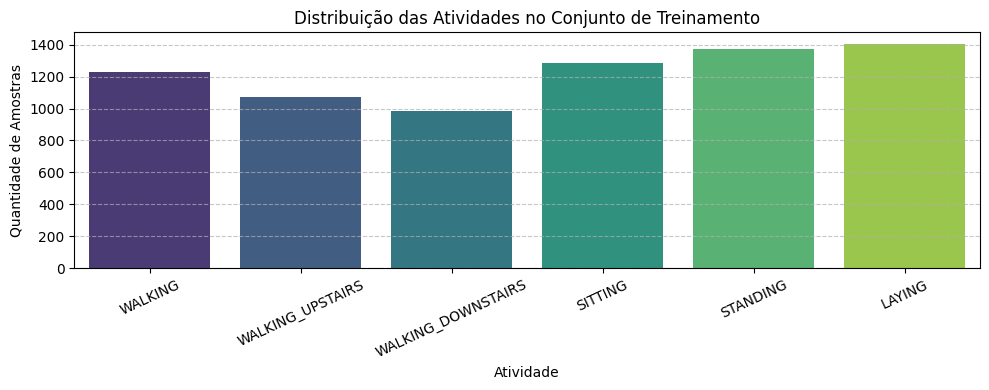

In [17]:
plt.figure(figsize=(10, 4))
sns.countplot(data=y_train, x='Activity_Name', order=activity_labels.values(), palette='viridis')
plt.title('Distribuição das Atividades no Conjunto de Treinamento')
plt.xlabel('Atividade')
plt.ylabel('Quantidade de Amostras')
plt.xticks(rotation=25)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Cálculo da Matriz de Covariância e Correlação de Pearson

In [18]:
cov_matrix = selected_cols.cov()
corr_matrix = selected_cols.corr()

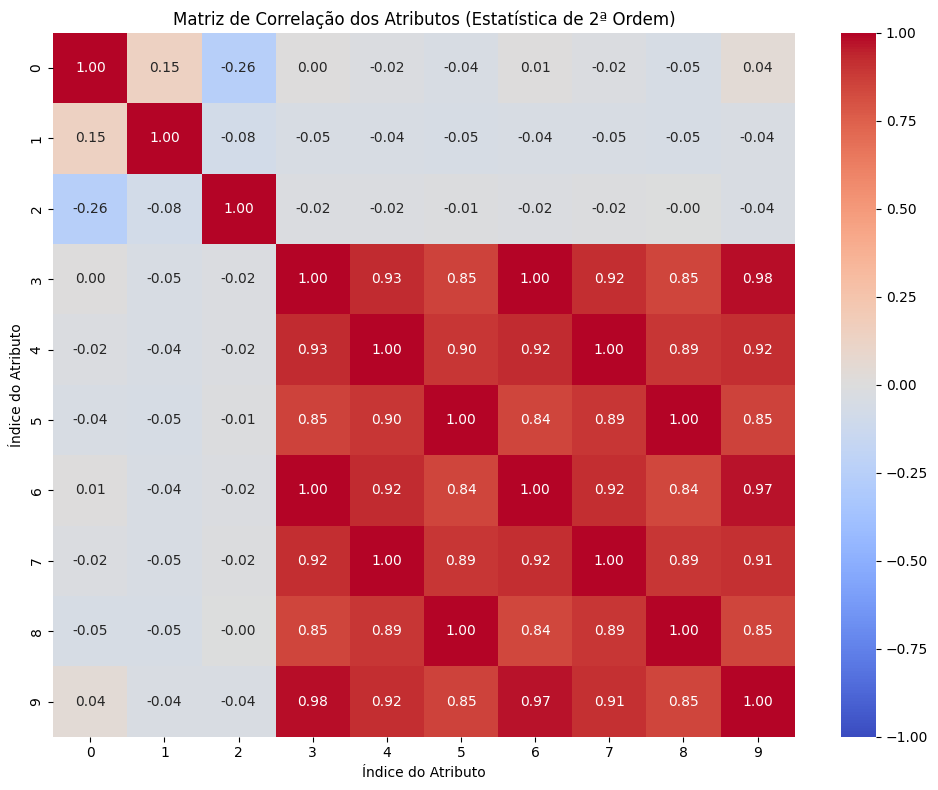

In [19]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, cbar=True)
plt.title('Matriz de Correlação dos Atributos (Estatística de 2ª Ordem)')
plt.xlabel('Índice do Atributo')
plt.ylabel('Índice do Atributo')
plt.tight_layout()
plt.show()

Correlação entre os atributos dos sensores e as atividades

In [20]:
df_analysis = X_train_norm.iloc[:, :8].copy()

In [21]:
activity_dummies = pd.get_dummies(y_train['Activity_Name'])

In [22]:
df_combined = pd.concat([df_analysis, activity_dummies], axis=1)

Calcular a Matriz de Correlação e Heatmap

In [23]:
corr_combined = df_combined.corr()

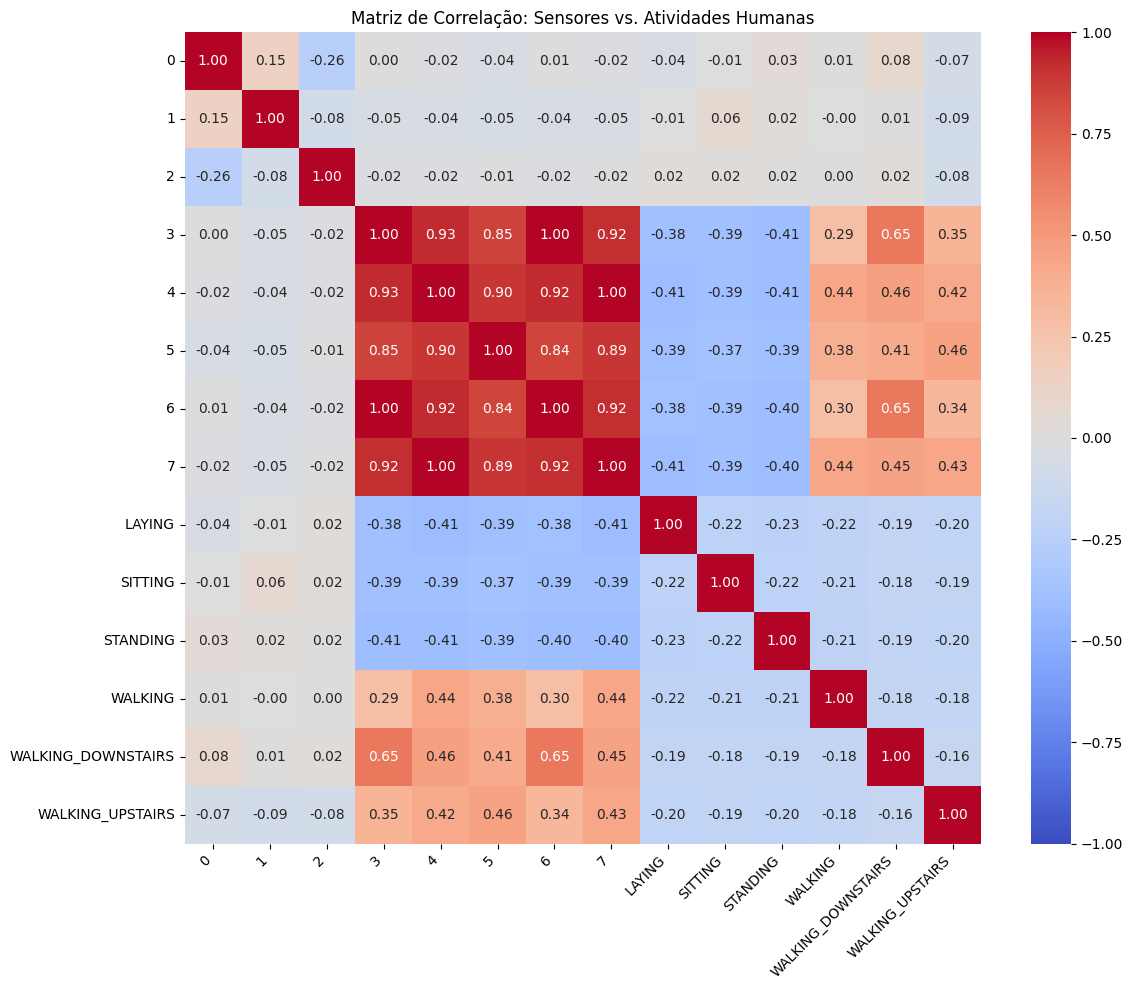

In [24]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr_combined, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, cbar=True)
plt.title('Matriz de Correlação: Sensores vs. Atividades Humanas')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()